#  Student Mental Health – Capstone Final Project
### Analyzing the Relationship Between GPA, Year of Study, and Mental Health
### Data4Change Program

## Step 1: Import Libraries & Load the Dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Student Mental Health dataset
url = 'https://raw.githubusercontent.com/KadenShubert/student-mentalhealth-eda/main/Student_Mental_health.csv'
df = pd.read_csv(url)

print('Dataset loaded successfully!')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully!
Shape: (101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## Step 2: Inspect the Data

In [5]:
# Check column names
print('Columns:', df.columns.tolist())
print()

# Metal detector - check for missing values
print('Missing values:')
print(df.isnull().sum())

Columns: ['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']

Missing values:
Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64


## Step 3: Clean the Data

In [6]:
# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Rename long column names to short ones
df = df.rename(columns={
    "What is your CGPA?": "CGPA",
    "Do you have Depression?": "Depression",
    "Do you have Anxiety?": "Anxiety",
    "Do you have Panic attack?": "Panic_Attack",
    "What is your course?": "Course",
    "Your current year of Study": "Year",
    "Choose your gender": "Gender",
    "What is your marital status?": "Marital_Status",
    "Did you seek any specialist for a treatment?": "Sought_Treatment"
})

# Drop rows with missing values in key columns
df = df.dropna(subset=["CGPA", "Depression", "Anxiety", "Year"])

# Fix Year column - strip spaces, lowercase, extract number, rebuild cleanly
# This handles "Year 1", "year 1", " year 1 " all becoming "Year 1"
df["Year"] = df["Year"].str.strip().str.lower().str.replace("year", "").str.strip()
df["Year"] = "Year " + df["Year"]

print("Unique Year values after fix:", df["Year"].unique())
print("After cleaning, shape:", df.shape)
df.head()

Unique Year values after fix: ['Year 1' 'Year 2' 'Year 3' 'Year 4']
After cleaning, shape: (101, 11)


,Timestamp,Gender,Age,Course,Year,CGPA,Marital status,Depression,Anxiety,Panic_Attack,Sought_Treatment
0,8/7/2020 12:02,Female,18.0,Engineering,Year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,Year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,Year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,No,No,No,No,No


## Step 4: Feature Engineering
### The CGPA column has ranges like '3.50 - 4.00' — we convert them to a single number (the midpoint) so we can do math on them!

In [7]:
# Convert CGPA range strings to numeric midpoint
def cgpa_to_midpoint(cgpa_str):
    try:
        parts = str(cgpa_str).split(' - ')
        return (float(parts[0]) + float(parts[1])) / 2
    except:
        return None

df['GPA_Numeric'] = df['CGPA'].apply(cgpa_to_midpoint)
df = df.dropna(subset=['GPA_Numeric'])

print('CGPA ranges converted to numeric midpoints:')
print(df[['CGPA', 'GPA_Numeric']].drop_duplicates().sort_values('GPA_Numeric'))

CGPA ranges converted to numeric midpoints:
            CGPA  GPA_Numeric
43      0 - 1.99        0.995
35   2.00 - 2.49        2.245
8    2.50 - 2.99        2.745
0    3.00 - 3.49        3.245
6   3.50 - 4.00         3.750
5    3.50 - 4.00        3.750


---
##  Chart 1 — Question 1
### Do students with depression tend to have a lower GPA?

  Depression  Average GPA
0         No     3.338561
1        Yes     3.389714


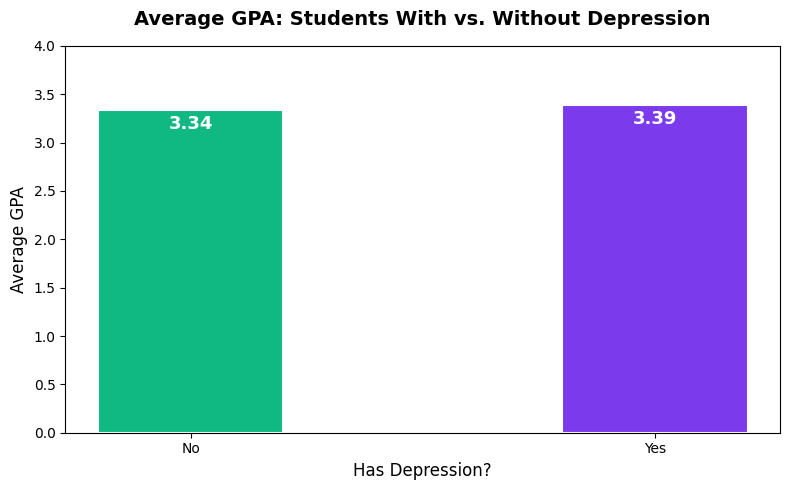

Saved: gpa-vs-depression.png


In [8]:
# Calculate average GPA for students with and without depression
gpa_by_depression = df.groupby('Depression')['GPA_Numeric'].mean().reset_index()
gpa_by_depression.columns = ['Depression', 'Average GPA']
print(gpa_by_depression)

# Plot
plt.figure(figsize=(8, 5))
colors = ['#10b981', '#7c3aed']
bars = plt.bar(gpa_by_depression['Depression'], gpa_by_depression['Average GPA'],
               color=colors, edgecolor='white', linewidth=1.5, width=0.4)

# Add value labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.05,
             f'{bar.get_height():.2f}',
             ha='center', va='top', color='white', fontweight='bold', fontsize=13)

plt.title('Average GPA: Students With vs. Without Depression', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Has Depression?', fontsize=12)
plt.ylabel('Average GPA', fontsize=12)
plt.ylim(0, 4.0)
plt.tight_layout()

# Save the chart!
plt.savefig('gpa-vs-depression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gpa-vs-depression.png')

---
##  Chart 2 — Question 2
### Which year of study has the highest rate of depression?

     Year  Depression Rate (%)
0  Year 1            32.558140
1  Year 2            38.461538
2  Year 3            41.666667
3  Year 4            12.500000


/tmp/ipykernel_29708/2015318535.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_depression, x='Year', y='Depression Rate (%)',


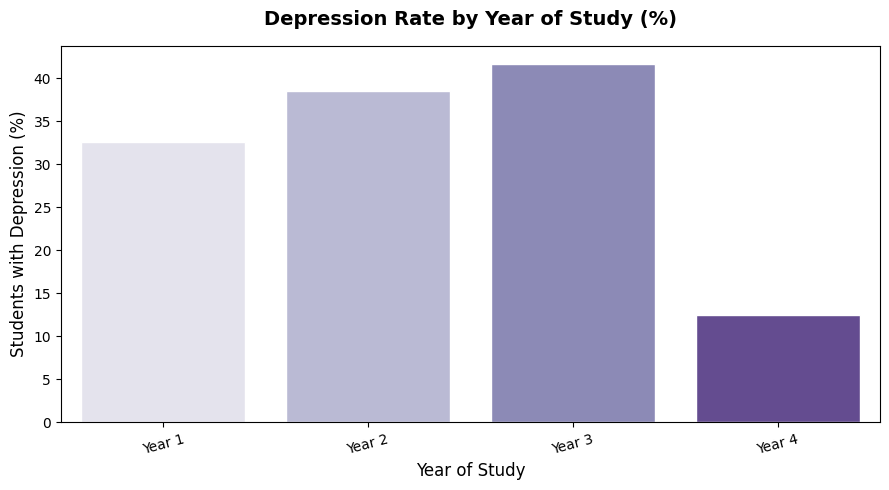

Saved: depression-by-year.png


In [9]:
# Calculate depression rate (%) per year of study
year_depression = df.groupby('Year')['Depression'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
year_depression.columns = ['Year', 'Depression Rate (%)']
year_depression = year_depression.sort_values('Year')
print(year_depression)

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(data=year_depression, x='Year', y='Depression Rate (%)',
            palette='Purples', edgecolor='white')

plt.title('Depression Rate by Year of Study (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year of Study', fontsize=12)
plt.ylabel('Students with Depression (%)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

# Save the chart!
plt.savefig('depression-by-year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: depression-by-year.png')

---
##  Chart 3 — Question 3
### Are students with anxiety more likely to also have depression?

Depression  No  Yes
Anxiety            
No          50   17
Yes         16   18


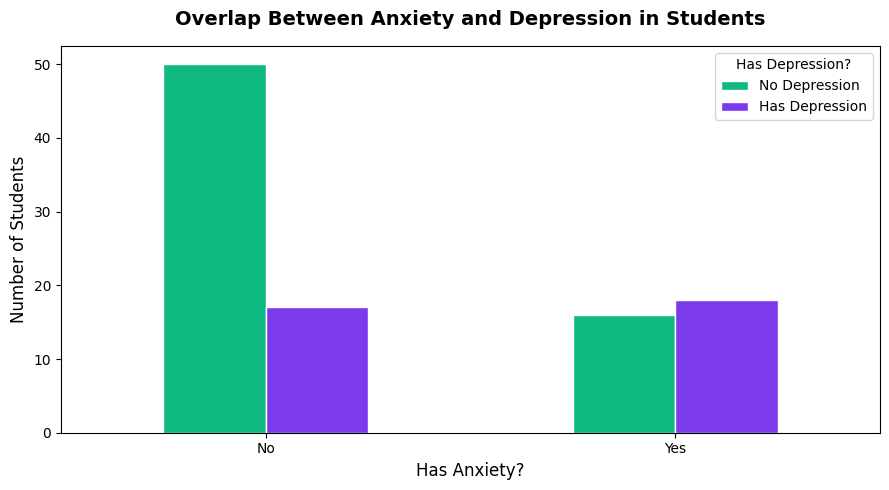

Saved: anxiety-depression-overlap.png


In [10]:
# Count students in each Anxiety + Depression combination
pivot = df.groupby(['Anxiety', 'Depression']).size().unstack(fill_value=0)
print(pivot)

# Plot as grouped bar chart
pivot.plot(kind='bar', color=['#10b981', '#7c3aed'], edgecolor='white',
           figsize=(9, 5), width=0.5)

plt.title('Overlap Between Anxiety and Depression in Students', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Has Anxiety?', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Has Depression?', labels=['No Depression', 'Has Depression'])
plt.tight_layout()

# Save the chart!
plt.savefig('anxiety-depression-overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: anxiety-depression-overlap.png')